In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
df_INFY = pd.read_csv("Data\IT_Data\INFY.NS_data.csv")

<>:1: SyntaxWarning: invalid escape sequence '\I'
<>:1: SyntaxWarning: invalid escape sequence '\I'
C:\Users\vishe\AppData\Local\Temp\ipykernel_11152\2169367024.py:1: SyntaxWarning: invalid escape sequence '\I'
  df_INFY = pd.read_csv("Data\IT_Data\INFY.NS_data.csv")


In [3]:
df_INFY.info()

<class 'pandas.DataFrame'>
RangeIndex: 2759 entries, 0 to 2758
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Price   2759 non-null   str  
 1   Close   2758 non-null   str  
 2   High    2758 non-null   str  
 3   Low     2758 non-null   str  
 4   Open    2758 non-null   str  
 5   Volume  2758 non-null   str  
dtypes: str(6)
memory usage: 129.5 KB


In [4]:
df_INFY.head()

,Price,Close,High,Low,Open,Volume
0,Ticker,INFY.NS,INFY.NS,INFY.NS,INFY.NS,INFY.NS
1,Date,NaN,NaN,NaN,NaN,NaN
2,2015-01-01,367.7708740234375,369.18651909497083,364.5111545056969,366.7556905879704,2002764
3,2015-01-02,374.9980773925781,376.0877731142453,367.32377635301776,367.32377635301776,6778320
4,2015-01-05,371.7756042480469,378.1273948554082,368.3482380919063,374.38337938498074,9937024


In [5]:
df_INFY.describe()

,Price,Close,High,Low,Open,Volume
count,2759,2758,2758,2758,2758,2758
unique,2759,2718,2756,2756,2755,2756
top,Ticker,374.57635498046875,1630.0,1490.5,1610.0,5919715
freq,1,2,2,2,2,2


In [6]:
df_INFY = df_INFY.rename(columns={'Price':'Date'})

In [7]:
df_INFY = df_INFY.iloc[2:].reset_index(drop=True)

In [8]:
df_INFY['Date'] = pd.to_datetime(df_INFY['Date'])

decimal_values = ["Close", "High", "Low", "Open", "Volume"]
numeric_values =["Volume"]

for i in decimal_values:
    df_INFY[i] = df_INFY[i].astype(float)

for j in numeric_values:
    df_INFY[j] = pd.to_numeric(df_INFY[j])

In [9]:
df_INFY = df_INFY.sort_values(by="Date").reset_index(drop=True)

### Visualize The Trends

In [10]:
import matplotlib.pyplot as plt

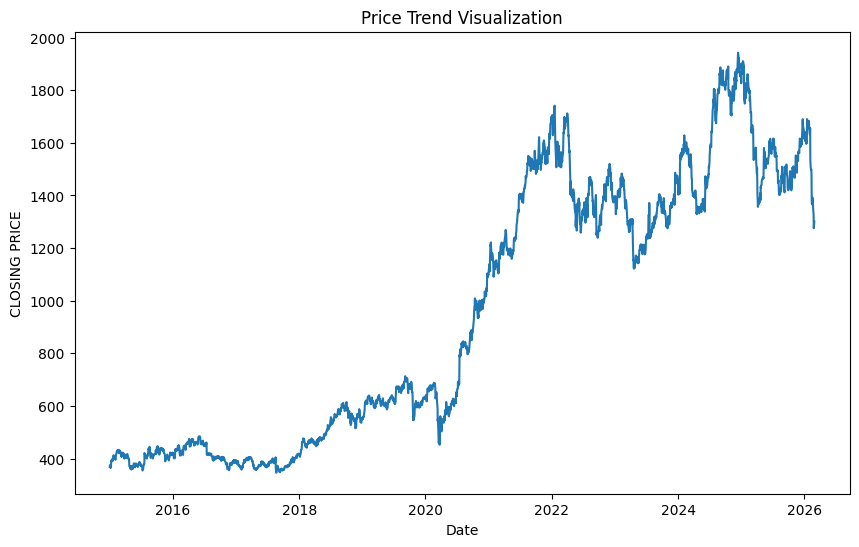

In [11]:
# Price Trend Over the Time
plt.figure(figsize=(10,6))
plt.plot(df_INFY['Date'], df_INFY['Close'], )
plt.title("Price Trend Visualization")
plt.xlabel("Date")
plt.ylabel("CLOSING PRICE")
plt.show()

<Figure size 1000x600 with 0 Axes>

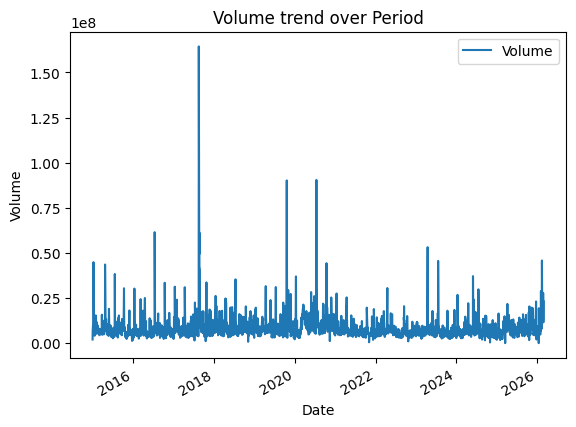

In [12]:
# Volume trend Over Time
plt.figure(figsize=(10,6))
df_INFY.plot(x='Date', y='Volume', kind='line', title="Volume trend over Period")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.show()

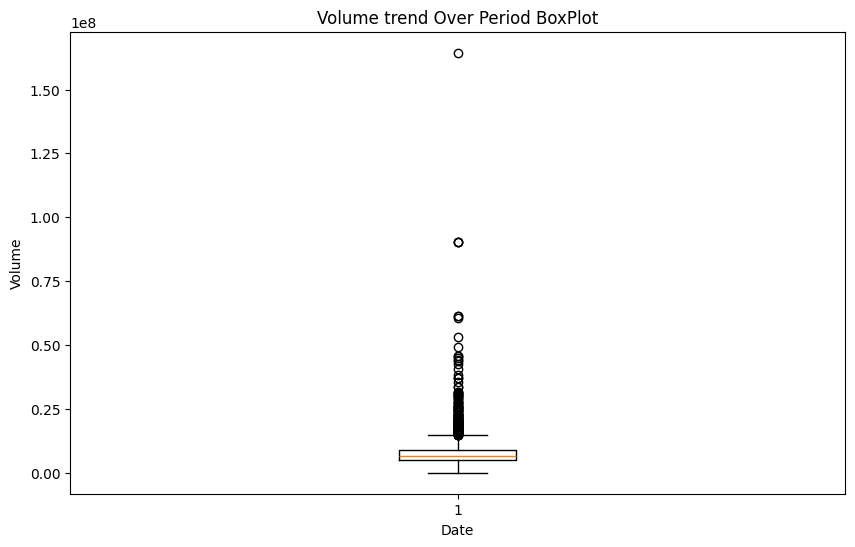

In [13]:
# The Line shows a Outlier in Volume . Check it using Box Plot
plt.figure(figsize=(10,6))
plt.boxplot(df_INFY["Volume"])
plt.title("Volume trend Over Period BoxPlot")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.show()

# Daily Returns on Stocks

In [14]:
def daily_returns(close_price):
    returns=[None]
    for i in range(1, len(close_price)):
        daily_return = (close_price[i] - close_price[i-1])/close_price[i-1]
        returns.append(daily_return)
    return returns

df_INFY['Daily_Returns'] = daily_returns(df_INFY['Close'])

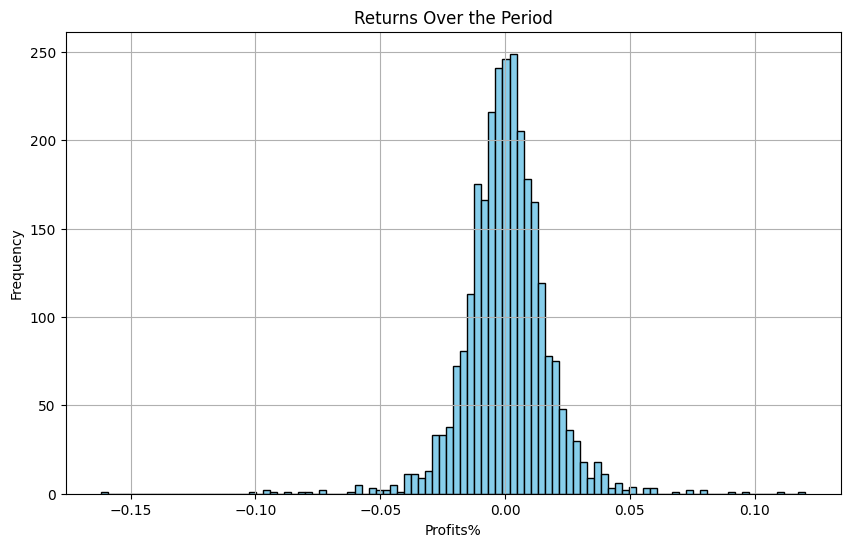

In [15]:
# Visualization of the Returns
plt.figure(figsize=(10,6))
plt.hist(df_INFY['Daily_Returns'], bins=100, color='skyblue', edgecolor='black')
plt.xlabel("Profits%")
plt.ylabel("Frequency")
plt.title("Returns Over the Period")
plt.grid(True)
plt.show()

In [16]:
df_INFY

,Date,Close,High,Low,Open,Volume,Daily_Returns
0,2015-01-01,367.770874,369.186519,364.511155,366.755691,2002764.0,NaN
1,2015-01-02,374.998077,376.087773,367.323776,367.323776,6778320.0,0.019651
2,2015-01-05,371.775604,378.127395,368.348238,374.383379,9937024.0,-0.008593
3,2015-01-06,364.008118,369.745232,360.264102,368.813883,9667316.0,-0.020893
4,2015-01-07,365.749756,367.835967,363.225793,366.019838,7249916.0,0.004785
...,...,...,...,...,...,...,...
2752,2026-02-23,1327.500000,1352.000000,1318.000000,1352.000000,12887826.0,-0.018992
2753,2026-02-24,1275.500000,1303.599976,1264.099976,1301.000000,27839061.0,-0.039171
2754,2026-02-25,1290.099976,1323.599976,1286.199951,1286.199951,16669618.0,0.011446
2755,2026-02-26,1289.099976,1314.000000,1286.300049,1305.500000,11493914.0,-0.000775


### Calculating Moving Averages Across the Range

In [17]:
df_INFY['MA_Week'] = df_INFY['Close'].rolling(window=7).mean()
df_INFY['MA_Month'] = df_INFY['Close'].rolling(window=30).mean()
df_INFY['MA_3Months'] = df_INFY['Close'].rolling(window=90).mean()

In [18]:
df_INFY.head(10)

,Date,Close,High,Low,Open,Volume,Daily_Returns,MA_Week,MA_Month,MA_3Months
0,2015-01-01,367.770874,369.186519,364.511155,366.755691,2002764.0,NaN,NaN,NaN,NaN
1,2015-01-02,374.998077,376.087773,367.323776,367.323776,6778320.0,0.019651,NaN,NaN,NaN
2,2015-01-05,371.775604,378.127395,368.348238,374.383379,9937024.0,-0.008593,NaN,NaN,NaN
3,2015-01-06,364.008118,369.745232,360.264102,368.813883,9667316.0,-0.020893,NaN,NaN,NaN
4,2015-01-07,365.749756,367.835967,363.225793,366.019838,7249916.0,0.004785,NaN,NaN,NaN
5,2015-01-08,367.593872,371.980532,363.225857,369.857053,13564920.0,0.005042,NaN,NaN,NaN
6,2015-01-09,386.407074,392.842700,356.343170,368.832537,44863328.0,0.051179,371.186196,NaN,NaN
7,2015-01-12,394.137299,394.742675,386.509565,389.676149,12758888.0,0.020005,374.952829,NaN,NaN
8,2015-01-13,389.098694,392.619218,386.509564,392.619218,8801236.0,-0.012784,376.967202,NaN,NaN
9,2015-01-14,396.502869,397.313160,389.787884,390.886857,9921260.0,0.019029,380.499669,NaN,NaN


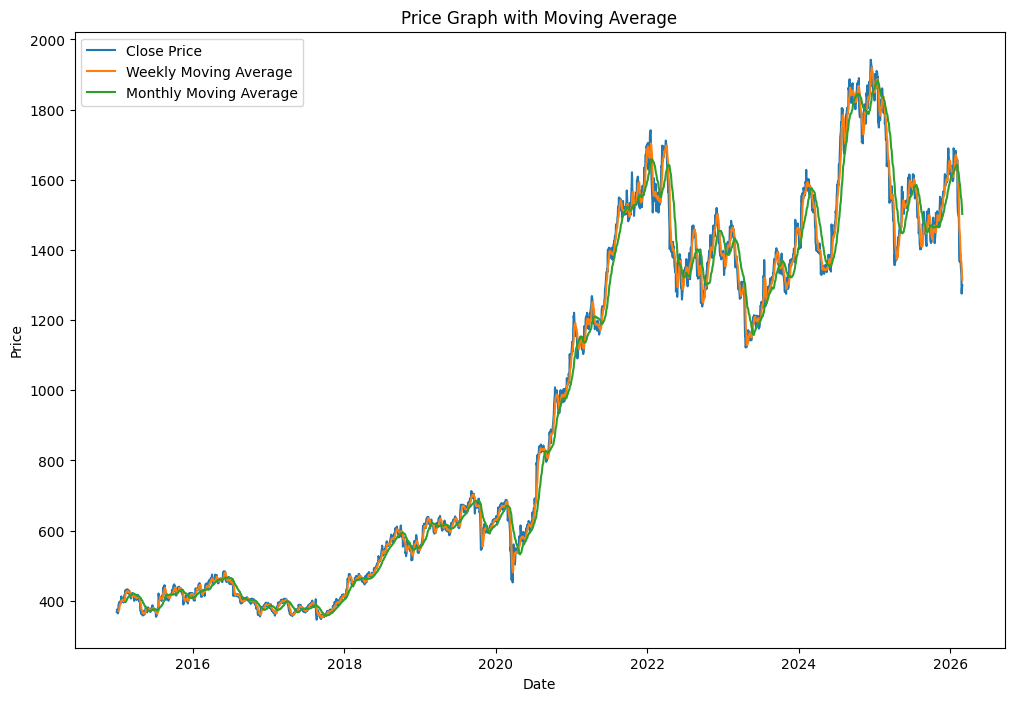

In [19]:
plt.figure(figsize=(12,8))
plt.plot(df_INFY['Date'], df_INFY['Close'], label='Close Price')
plt.plot(df_INFY['Date'], df_INFY['MA_Week'], label='Weekly Moving Average')
plt.plot(df_INFY['Date'], df_INFY['MA_Month'], label="Monthly Moving Average")
plt.title("Price Graph with Moving Average")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

In [20]:
df_INFY.isnull().sum()

Date              0
Close             0
High              0
Low               0
Open              0
Volume            0
Daily_Returns     1
MA_Week           6
MA_Month         29
MA_3Months       89
dtype: int64

c:\Users\vishe\OneDrive\Desktop\SUL_PROJECT\.venv\Lib\site-packages\mplfinance\_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


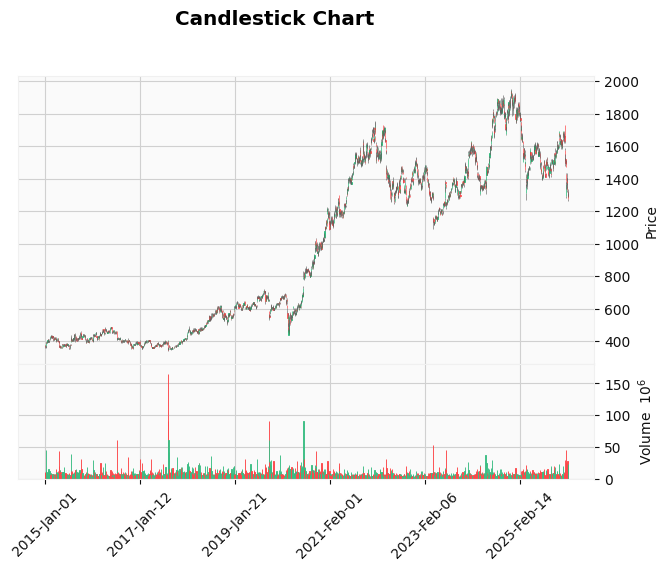

In [21]:
# CandleStick type of Chart
import mplfinance as mpf


# before that set the date column as index column
df_INFY = df_INFY.set_index('Date')
df_INFY = df_INFY.sort_index()

mpf.plot(df_INFY, type='candle', style='yahoo', title=f'Candlestick Chart', volume=True)


In [22]:
# Volatility to Measure the High Risk Periods
df_INFY['volatility'] = df_INFY['Daily_Returns'].rolling(window=3).std()

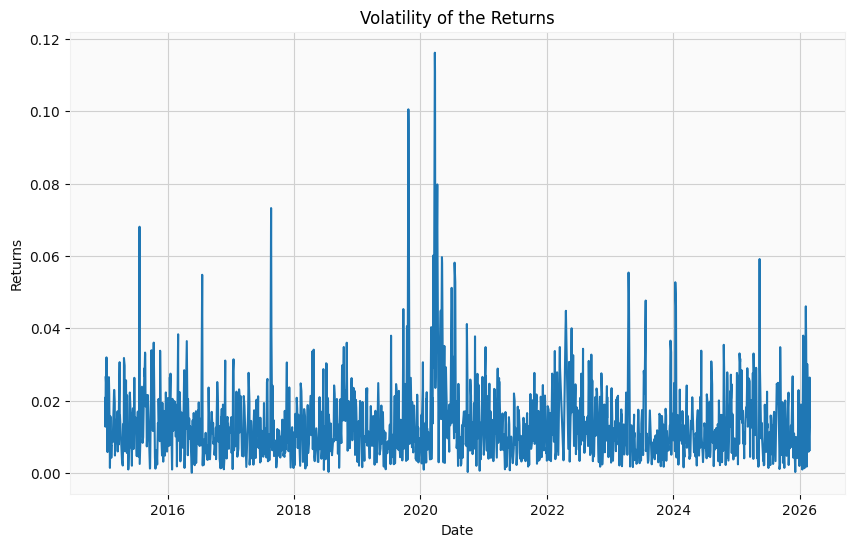

In [23]:
# Plot Date VS Volatily
plt.figure(figsize=(10,6))
plt.plot(df_INFY.index,df_INFY['volatility'])
plt.title("Volatility of the Returns")
plt.xlabel("Date")
plt.ylabel("Returns")
plt.show()

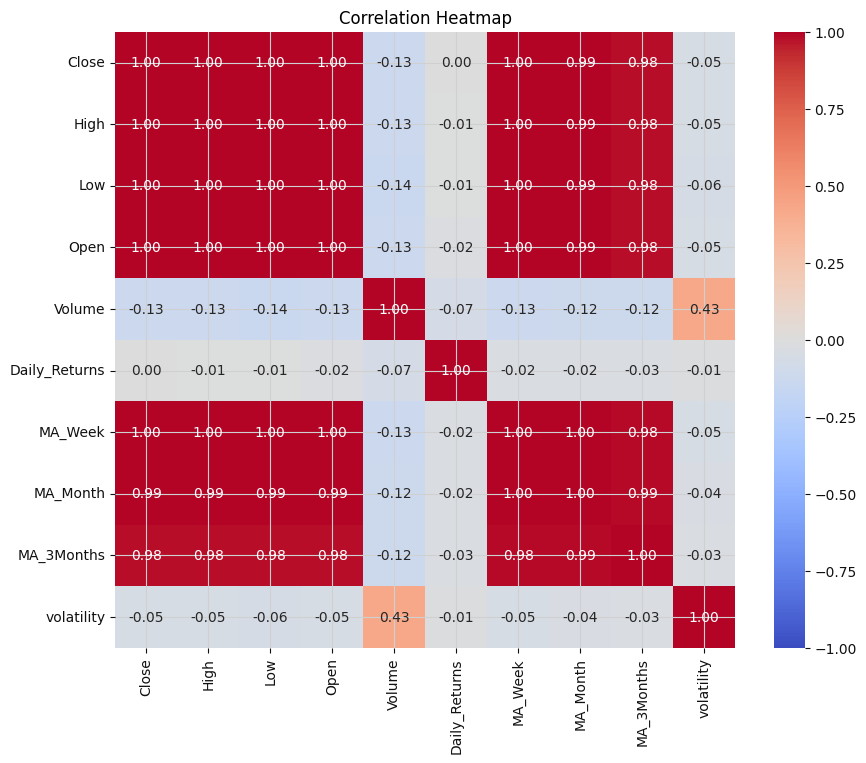

In [24]:
# Check the Correlation between all the calculated values
corr_matrix = df_INFY.select_dtypes('number').corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title("Correlation Heatmap")
plt.show()

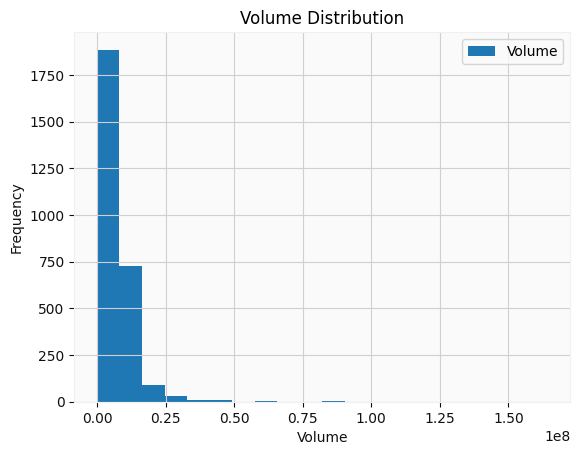

In [25]:
# Plot Histogram for Volume to check for trading activity 
df_INFY.plot(kind='hist', y='Volume', bins=20, title='Volume Distribution')
plt.xlabel("Volume")
plt.show()

In [26]:
# Computing RSI (Relative Strength Index) , it measures speed and magnitude of Price Movements

# RSI compares (Average Gains VS Average Losses)

delta = df_INFY['Close'].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()

rs = avg_gain/avg_loss

df_INFY['RSI'] = 100-(100/(1+rs))

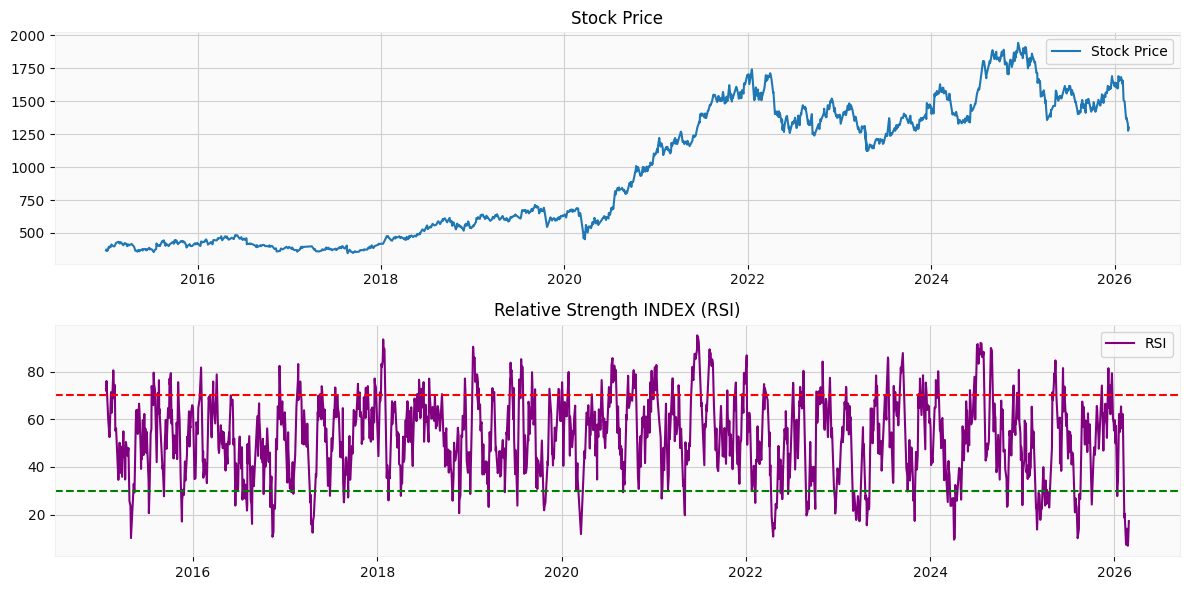

In [27]:
plt.figure(figsize=(12,6))
plt.subplot(2,1,1)
plt.plot(df_INFY['Close'], label= "Stock Price")
plt.title("Stock Price")
plt.legend()

plt.subplot(2,1,2)
plt.plot(df_INFY['RSI'], label='RSI', color='purple')
plt.axhline(70, linestyle='--', color='red')  # threshold when stock is overbought
plt.axhline(30, linestyle='--', color='green') # threshold when stock is oversold

plt.title("Relative Strength INDEX (RSI)")

plt.legend()
plt.tight_layout()
plt.show()

### Creating Prediction Target

In [28]:
# if next day's return > 0 then target = 1 else 0


df_INFY['Next_Day_Return'] = df_INFY['Daily_Returns'].shift(-1)
df_INFY['Target'] = (df_INFY['Next_Day_Return'] > 0).astype(int)

In [29]:
df_INFY = df_INFY.dropna()

In [30]:
df_INFY.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2667 entries, 2015-05-15 to 2026-02-26
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Close            2667 non-null   float64
 1   High             2667 non-null   float64
 2   Low              2667 non-null   float64
 3   Open             2667 non-null   float64
 4   Volume           2667 non-null   float64
 5   Daily_Returns    2667 non-null   float64
 6   MA_Week          2667 non-null   float64
 7   MA_Month         2667 non-null   float64
 8   MA_3Months       2667 non-null   float64
 9   volatility       2667 non-null   float64
 10  RSI              2667 non-null   float64
 11  Next_Day_Return  2667 non-null   float64
 12  Target           2667 non-null   int64  
dtypes: float64(12), int64(1)
memory usage: 291.7 KB


### Time Based Train Test Split

In [31]:
df_INFY = df_INFY.sort_index()
split_index = int(len(df_INFY)*0.8)

train = df_INFY.iloc[0:split_index]
test = df_INFY.iloc[split_index: len(df_INFY)]


print(f"Training ENDS: {train.index.max()}")
print(f"Testing Starts: {test.index.min()}")

Training ENDS: 2024-01-01 00:00:00
Testing Starts: 2024-01-02 00:00:00


In [32]:
y_train = train['Target']
y_test = test['Target']



features=['Daily_Returns', 'Volume', 'volatility', 'MA_Week', 'MA_Month', 'MA_3Months', 'RSI']
X_train = train[features]
X_test = test[features]

### Fearture Scaling

In [33]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()